In [13]:
# ============================================================
# CELL 1: IMPORTS AND CONFIG
# ============================================================
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from shapely.geometry import Point
import warnings
warnings.filterwarnings('ignore')

LOCAL_DIR = Path("C:\\Users\\admin\\Documents\\Glacier Project")
PIXEL_AREA_M2 = 100  # 10m × 10m

# Which model's predictions to use as primary
# (you have prob_mlp and prob_easd in your predictions parquet)
PRIMARY_MODEL = 'prob_mlp_ae64_nostrat'
BASELINE_MODEL = 'prob_rf_easd_nostrat'

print('Imports done.')

Imports done.


In [2]:
# ============================================================
# CELL 2: LOAD PREDICTIONS AND RGI POLYGONS
# ============================================================
print('Loading predictions...')
df = pd.read_parquet(LOCAL_DIR / 'Predictions\\predictions_full_peru.parquet')
print(f'Predictions: {len(df):,} pixels')
print(f'Columns: {df.columns.tolist()}')
print(f'Melt rate: {df["melt_label"].mean()*100:.2f}%')

# Sanity check we have probabilities
assert PRIMARY_MODEL in df.columns, f'{PRIMARY_MODEL} not in predictions'
assert BASELINE_MODEL in df.columns, f'{BASELINE_MODEL} not in predictions'

print('\nLoading RGI polygons...')
rgi = gpd.read_file(LOCAL_DIR / 'rgi70_peru.geojson')
print(f'RGI glaciers: {len(rgi):,}')
print(f'RGI columns: {rgi.columns.tolist()}')
print(f'CRS: {rgi.crs}')

Loading predictions...
Predictions: 15,242,639 pixels
Columns: ['region', 'lon', 'lat', 'melt_label', 'edge_distance', 'prob_mlp_ae64_nostrat', 'prob_rf_easd_nostrat']
Melt rate: 19.50%

Loading RGI polygons...
RGI glaciers: 3,695
RGI columns: ['id', 'anlys_id', 'area_km2', 'aspect_deg', 'aspect_sec', 'cenlat', 'cenlon', 'conn_lvl', 'dem_source', 'glac_name', 'glims_id', 'is_rgi6', 'lmax_m', 'o1region', 'o2region', 'primeclass', 'rgi_id', 'slope_deg', 'src_date', 'subm_id', 'surge_type', 'term_type', 'termlat', 'termlon', 'utm_zone', 'zmax_m', 'zmean_m', 'zmed_m', 'zmin_m', 'geometry']
CRS: EPSG:4326


In [3]:
# ============================================================
# CELL 3: BUILD GEODATAFRAME FROM PIXEL PREDICTIONS
#
# Converts the predictions DataFrame into a GeoDataFrame so we
# can do spatial joins against RGI polygons.
# With 15M points this takes a minute or two.
# ============================================================
print('Building pixel GeoDataFrame...')
print('(This may take 1-2 minutes for 15M points)')

import time
t0 = time.time()

gdf_pixels = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['lon'], df['lat']),
    crs='EPSG:4326'
)
print(f'GeoDataFrame built in {time.time()-t0:.1f}s')
print(f'Memory: {gdf_pixels.memory_usage(deep=True).sum() / 1e9:.2f} GB')

Building pixel GeoDataFrame...
(This may take 1-2 minutes for 15M points)
GeoDataFrame built in 11.2s
Memory: 0.71 GB


In [4]:
# ============================================================
# CELL 4: SPATIAL JOIN - ASSIGN EACH PIXEL TO ITS RGI GLACIER
#
# Uses geopandas spatial index (STRtree) internally so this is
# much faster than a naive loop. Pixels outside any RGI polygon
# get NaN for glacier_id and are dropped.
#
# With 15M points and ~1500 polygons expect 5-20 minutes.
# Progress is hard to show for spatial joins so just let it run.
# ============================================================
print('Running spatial join (pixels → RGI polygons)...')
print('This will take 5-20 minutes. Let it run.')
t0 = time.time()

# Make sure RGI is in same CRS
rgi_4326 = rgi.to_crs('EPSG:4326')

# Spatial join: each pixel gets the attributes of the polygon it falls in
# 'within' predicate: pixel must be strictly inside a polygon
joined = gpd.sjoin(
    gdf_pixels,
    rgi_4326[['geometry', 'rgi_id', 'area_km2']],  # only keep what we need
    how='left',
    predicate='within'
)

elapsed = time.time() - t0
print(f'Spatial join done in {elapsed/60:.1f} minutes')
print(f'Total pixels: {len(joined):,}')
print(f'Pixels inside an RGI polygon: {joined["rgi_id"].notna().sum():,}')
print(f'Pixels outside all polygons: {joined["rgi_id"].isna().sum():,}')

Running spatial join (pixels → RGI polygons)...
This will take 5-20 minutes. Let it run.
Spatial join done in 0.6 minutes
Total pixels: 15,242,639
Pixels inside an RGI polygon: 13,545,756
Pixels outside all polygons: 1,696,883


In [5]:
# ============================================================
# CELL 5: COMPUTE THRESHOLDED PREDICTIONS PER GLACIER
#
# For the spatial overlap metric, we need to threshold the
# probability map to match the observed melt area.
# We do this globally (same as before) and then evaluate per glacier.
#
# NOTE: We use the global threshold because that's what Darina uses.
# Per-glacier thresholding would be a different (arguably better)
# metric but wouldn't be comparable to prior work.
# ============================================================
print('Computing global threshold...')

n_actual_melt = (joined['melt_label'] == 1).sum()

# Get threshold that selects exactly n_actual_melt pixels
probs_array = joined[PRIMARY_MODEL].values
top_indices = np.argsort(probs_array)[::-1][:n_actual_melt]
threshold = probs_array[top_indices[-1]]
print(f'Global threshold: {threshold:.4f}')
print(f'Actual melt pixels: {n_actual_melt:,}')

# Apply threshold
joined['predicted_melt'] = (joined[PRIMARY_MODEL] >= threshold).astype(int)
joined['predicted_melt_baseline'] = (joined[BASELINE_MODEL] >= threshold).astype(int)

# Quick sanity check
print(f'Predicted melt pixels (primary): {joined["predicted_melt"].sum():,}')
print(f'Actual melt pixels: {n_actual_melt:,}')

Computing global threshold...
Global threshold: 0.8734
Actual melt pixels: 2,971,684
Predicted melt pixels (primary): 2,971,685
Actual melt pixels: 2,971,684


In [6]:
# ============================================================
# CELL 6: PER-GLACIER OVERLAP STATISTICS
#
# For each RGI glacier, compute:
#   - n_pixels: total ice pixels in glacier
#   - n_actual_melt: pixels that actually melted
#   - n_predicted_melt: pixels predicted as melt
#   - n_correct: pixels correctly predicted as melt (intersection)
#   - overlap_pct: n_correct / n_actual_melt * 100 (Darina's metric)
#   - iou: n_correct / union
#   - actual_melt_rate: n_actual_melt / n_pixels * 100
# ============================================================
print('Computing per-glacier statistics...')

# Only work with pixels inside an RGI polygon
df_inside = joined.dropna(subset=['rgi_id']).copy()
print(f'Working with {len(df_inside):,} pixels inside RGI polygons')

def glacier_stats(group, pred_col='predicted_melt'):
    n_total = len(group)
    n_actual = group['melt_label'].sum()
    n_predicted = group[pred_col].sum()
    n_correct = ((group['melt_label'] == 1) & (group[pred_col] == 1)).sum()
    n_union = ((group['melt_label'] == 1) | (group[pred_col] == 1)).sum()
    
    overlap_pct = (n_correct / n_actual * 100) if n_actual > 0 else np.nan
    iou = (n_correct / n_union) if n_union > 0 else np.nan
    actual_melt_rate = (n_actual / n_total * 100) if n_total > 0 else np.nan
    
    return pd.Series({
        'n_pixels': n_total,
        'area_km2': group['area_km2'].iloc[0],
        'n_actual_melt': n_actual,
        'n_predicted_melt': n_predicted,
        'n_correct': n_correct,
        'overlap_pct': overlap_pct,
        'iou': iou,
        'actual_melt_rate': actual_melt_rate,
    })

# Apply per glacier for primary model
print('Computing primary model stats...')
glacier_df = df_inside.groupby('rgi_id').apply(
    glacier_stats, pred_col='predicted_melt'
).reset_index()

# Apply per glacier for baseline model  
print('Computing baseline model stats...')
glacier_df_baseline = df_inside.groupby('rgi_id').apply(
    glacier_stats, pred_col='predicted_melt_baseline'
).reset_index()
glacier_df['overlap_pct_baseline'] = glacier_df_baseline['overlap_pct']
glacier_df['iou_baseline'] = glacier_df_baseline['iou']

# Drop glaciers with very few pixels or no actual melt
# (small glaciers dominated by noise give misleading stats)
glacier_df = glacier_df.dropna(subset=['overlap_pct'])
glacier_df_valid = glacier_df[glacier_df['n_actual_melt'] >= 10].copy()

print(f'\nTotal glaciers with pixels: {len(glacier_df):,}')
print(f'Glaciers with ≥10 melt pixels: {len(glacier_df_valid):,}')
print(f'\nPrimary model ({PRIMARY_MODEL}):')
print(f'  Mean overlap: {glacier_df_valid["overlap_pct"].mean():.2f}%')
print(f'  Median overlap: {glacier_df_valid["overlap_pct"].median():.2f}%')
print(f'  Std overlap: {glacier_df_valid["overlap_pct"].std():.2f}%')
print(f'\nBaseline model ({BASELINE_MODEL}):')
print(f'  Mean overlap: {glacier_df_valid["overlap_pct_baseline"].mean():.2f}%')
print(f'  Median overlap: {glacier_df_valid["overlap_pct_baseline"].median():.2f}%')
print(f'  Std overlap: {glacier_df_valid["overlap_pct_baseline"].std():.2f}%')

# Save
glacier_df_valid.to_csv(LOCAL_DIR / 'per_glacier_overlap.csv', index=False)
print('\nSaved per_glacier_overlap.csv')

Computing per-glacier statistics...
Working with 13,545,756 pixels inside RGI polygons
Computing primary model stats...
Computing baseline model stats...

Total glaciers with pixels: 2,649
Glaciers with ≥10 melt pixels: 2,579

Primary model (prob_mlp_ae64_nostrat):
  Mean overlap: 77.75%
  Median overlap: 79.76%
  Std overlap: 16.92%

Baseline model (prob_rf_easd_nostrat):
  Mean overlap: 60.01%
  Median overlap: 59.00%
  Std overlap: 18.40%

Saved per_glacier_overlap.csv


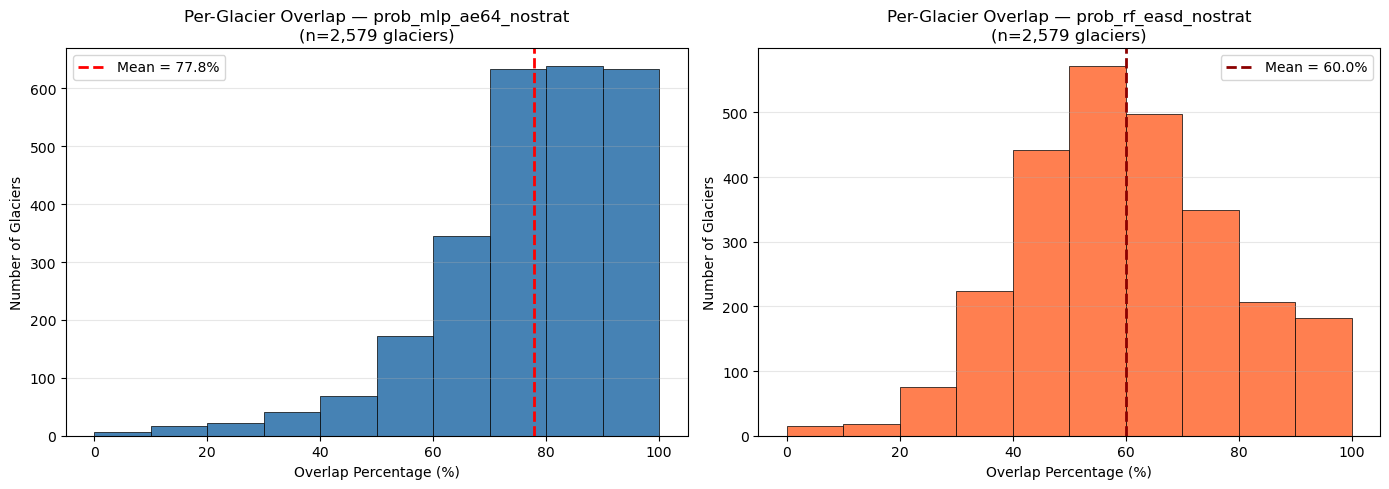

Saved histogram. Reference: Darina mean per-glacier overlap was 78%.


In [7]:
# ============================================================
# CELL 7: HISTOGRAM PLOTS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0, 101, 10)

# Primary model histogram
axes[0].hist(glacier_df_valid['overlap_pct'], bins=bins, 
             color='steelblue', edgecolor='black', linewidth=0.5)
mean_primary = glacier_df_valid['overlap_pct'].mean()
axes[0].axvline(mean_primary, color='red', linestyle='--', linewidth=2,
                label=f'Mean = {mean_primary:.1f}%')
axes[0].set_xlabel('Overlap Percentage (%)')
axes[0].set_ylabel('Number of Glaciers')
axes[0].set_title(f'Per-Glacier Overlap — {PRIMARY_MODEL}\n'
                  f'(n={len(glacier_df_valid):,} glaciers)')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Baseline model histogram
axes[1].hist(glacier_df_valid['overlap_pct_baseline'], bins=bins,
             color='coral', edgecolor='black', linewidth=0.5)
mean_baseline = glacier_df_valid['overlap_pct_baseline'].mean()
axes[1].axvline(mean_baseline, color='darkred', linestyle='--', linewidth=2,
                label=f'Mean = {mean_baseline:.1f}%')
axes[1].set_xlabel('Overlap Percentage (%)')
axes[1].set_ylabel('Number of Glaciers')
axes[1].set_title(f'Per-Glacier Overlap — {BASELINE_MODEL}\n'
                  f'(n={len(glacier_df_valid):,} glaciers)')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(LOCAL_DIR / 'per_glacier_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved histogram. Reference: Darina mean per-glacier overlap was 78%.')

In [12]:
# ============================================================
# CELL 8: SELECT REPRESENTATIVE GLACIERS FOR VISUALISATION
#
# Selection criteria (following Darina's approach):
#   - Range of sizes: 2 small, 2 medium, 2 large
#   - Range of performance: 3 above mean, 3 below mean
#   - Geographic spread across regions if possible
#   - Minimum 50 actual melt pixels (for meaningful visualisation)
# ============================================================
df_sel = glacier_df_valid[glacier_df_valid['n_actual_melt'] >= 50].copy()

# Define size categories by area tertiles
q33 = df_sel['area_km2'].quantile(0.33)
q67 = df_sel['area_km2'].quantile(0.67)
df_sel['size_cat'] = pd.cut(
    df_sel['area_km2'],
    bins=[-np.inf, q33, q67, np.inf],
    labels=['small', 'medium', 'large']
)
df_sel['above_mean'] = df_sel['overlap_pct'] > mean_primary

print(f'Size thresholds: small < {q33:.2f} km², '
      f'medium {q33:.2f}-{q67:.2f} km², large > {q67:.2f} km²')
print(f'\nGlacier counts per size:')
print(df_sel['size_cat'].value_counts())

selected = []
for size in ['small', 'medium', 'large']:
    size_group = df_sel[df_sel['size_cat'] == size].copy()
    
    if len(size_group) < 2:
        continue
    
    # One well-performing: highest overlap in this size category
    best = size_group.nlargest(1, 'overlap_pct')
    selected.append(best.iloc[0])
    
    # One poorly-performing: lowest overlap in this size category
    worst = size_group.nsmallest(1, 'overlap_pct')
    selected.append(worst.iloc[0])

selected_df = pd.DataFrame(selected).reset_index(drop=True)
selected_df['label'] = [f'({chr(97+i)})' for i in range(len(selected_df))]

print(selected_df[['label', 'rgi_id', 'area_km2', 
                   'overlap_pct', 'size_cat']].to_string())

selected_df.to_csv(LOCAL_DIR / 'selected_glaciers.csv', index=False)
print('\nSaved selected_glaciers.csv')

Size thresholds: small < 0.11 km², medium 0.11-0.44 km², large > 0.44 km²

Glacier counts per size:
size_cat
medium    780
small     759
large     759
Name: count, dtype: int64
  label                   rgi_id  area_km2  overlap_pct size_cat
0   (a)  RGI2000-v7.0-G-16-00121  0.046388   100.000000    small
1   (b)  RGI2000-v7.0-G-16-00911  0.092426    12.790698    small
2   (c)  RGI2000-v7.0-G-16-01028  0.185402   100.000000   medium
3   (d)  RGI2000-v7.0-G-16-00408  0.186833    20.000000   medium
4   (e)  RGI2000-v7.0-G-16-02592  0.503147    99.867667    large
5   (f)  RGI2000-v7.0-G-16-01650  2.106297    35.208471    large

Saved selected_glaciers.csv


In [10]:
# ============================================================
# CELL 10: SUMMARY TABLE FOR REPORT
# ============================================================
print('=== HEADLINE RESULTS ===')
print(f'\nPrimary model: {PRIMARY_MODEL}')
print(f'  Total spatial overlap (global): '
      f'{(joined["melt_label"] == joined["predicted_melt"]).mean()*100:.1f}% '
      f'(NOTE: this is accuracy not overlap - use your saved overlap % from earlier)')
print(f'  Mean per-glacier overlap: {mean_primary:.2f}%')
print(f'  Median per-glacier overlap: '
      f'{glacier_df_valid["overlap_pct"].median():.2f}%')
print(f'  % of glaciers above 60% overlap: '
      f'{(glacier_df_valid["overlap_pct"] > 60).mean()*100:.1f}%')
print(f'  % of glaciers above 80% overlap: '
      f'{(glacier_df_valid["overlap_pct"] > 80).mean()*100:.1f}%')

print(f'\nBaseline model: {BASELINE_MODEL}')
print(f'  Mean per-glacier overlap: {mean_baseline:.2f}%')
print(f'  Median per-glacier overlap: '
      f'{glacier_df_valid["overlap_pct_baseline"].median():.2f}%')

print(f'\nReference: Darina (2024) mean per-glacier overlap was 78%')

print('\n=== SELECTED GLACIERS SUMMARY ===')
print(selected_df[['label', 'rgi_id', 'area_km2', 
                   'actual_melt_rate', 'overlap_pct', 
                   'overlap_pct_baseline', 'size_cat']].to_string())

=== HEADLINE RESULTS ===

Primary model: prob_mlp_ae64_nostrat
  Total spatial overlap (global): 92.0% (NOTE: this is accuracy not overlap - use your saved overlap % from earlier)
  Mean per-glacier overlap: 77.75%
  Median per-glacier overlap: 79.76%
  % of glaciers above 60% overlap: 87.2%
  % of glaciers above 80% overlap: 49.2%

Baseline model: prob_rf_easd_nostrat
  Mean per-glacier overlap: 60.01%
  Median per-glacier overlap: 59.00%

Reference: Darina (2024) mean per-glacier overlap was 78%

=== SELECTED GLACIERS SUMMARY ===
  label                   rgi_id  area_km2  actual_melt_rate  overlap_pct  overlap_pct_baseline size_cat
0   (a)  RGI2000-v7.0-G-16-00688  0.029556         60.736196    77.777778             84.848485    small
1   (b)  RGI2000-v7.0-G-16-02760  0.066641         87.037037    77.659574             82.978723    small
2   (c)  RGI2000-v7.0-G-16-02246  0.256501         29.378238    77.777778             59.435626   medium
3   (d)  RGI2000-v7.0-G-16-02993  0.283724